In [1]:
# Numerical libraries
import numpy as np   

from sklearn.model_selection import train_test_split

# Import Linear Regression machine learning library
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

# to handle data in form of rows and columns 
import pandas as pd    

# importing ploting libraries
import matplotlib.pyplot as plt   

#importing seaborn for statistical plots
import seaborn as sns
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore

In [2]:
# reading the CSV file into pandas dataframe
mpg_df = pd.read_csv("car.csv",index_col='car name')  

In [3]:
mpg_df.head()

,cyl,disp,hp,wt,acc,yr,mpg
car name,,,,,,,
chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
buick skylark 320,8,350.0,165,3693,11.5,70,15.0
plymouth satellite,8,318.0,150,3436,11.0,70,18.0
amc rebel sst,8,304.0,150,3433,12.0,70,16.0
ford torino,8,302.0,140,3449,10.5,70,17.0


In [4]:
mpg_df.describe().transpose()  

,count,mean,std,min,25%,50%,75%,max
cyl,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
disp,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
wt,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acc,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
yr,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6


In [5]:
# hp is missing

In [6]:
mpg_df.dtypes

cyl       int64
disp    float64
hp       object
wt        int64
acc     float64
yr        int64
mpg     float64
dtype: object

In [7]:
# horsepower is an object type though it is supposed to be numeric. Check if all the rows in this column are digits 

temp = pd.DataFrame(mpg_df.hp.str.isdigit())  # if the string is made of digits store True else False  in the hp column 
temp[temp['hp'] == False]   # from temp take only those rows where hp has false

# On inspecting records number 32, 126 etc, we find "?" in the columns. Replace them with "nan"
#Replace them with nan and remove the records from the data frame that have "nan"
mpg_df = mpg_df.replace('?', np.nan)
mpg_df = mpg_df.apply(lambda x: x.fillna(x.median()),axis=0)


# converting the hp column from object / string type to float
mpg_df['hp'] = mpg_df['hp'].astype('float64')  


In [8]:
mpg_df.dtypes

cyl       int64
disp    float64
hp      float64
wt        int64
acc     float64
yr        int64
mpg     float64
dtype: object

In [9]:
mpg_df.isnull().any()

cyl     False
disp    False
hp      False
wt      False
acc     False
yr      False
mpg     False
dtype: bool

In [10]:
# no data seems to be missing

In [11]:
print('?' in mpg_df.hp)

False


In [12]:
# no ? in hp column  

In [13]:
mpg_df.shape

(398, 7)

In [14]:
mpg_df.describe()

,cyl,disp,hp,wt,acc,yr,mpg
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,23.514573
std,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,7.815984
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,9.000000
25%,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,17.500000
50%,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,23.000000
75%,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,29.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,46.600000


In [15]:
mpg_df.mpg.describe()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

In [16]:
# So the minimum value is 9 and maximum is 46, but on average it is 23.51 with a variation of 7.8

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


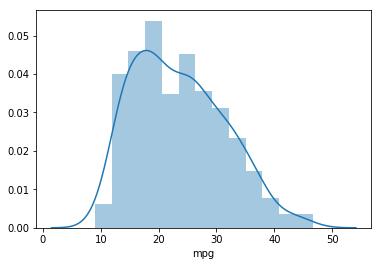

In [17]:
sns.distplot (mpg_df['mpg'])

In [18]:
print("Skewness: %f" % mpg_df['mpg'].skew())
print("Kurtosis: %f" % mpg_df['mpg'].kurt())

Skewness: 0.457066
Kurtosis: -0.510781


In [19]:
def scale(a):
    b = (a-a.min())/(a.max()-a.min())
    return b


In [20]:
mpg_df_scale = mpg_df.copy()

In [21]:
mpg_df_scale ['disp'] = scale(mpg_df_scale['disp'])
mpg_df_scale['hp'] = scale(mpg_df_scale['hp'])
mpg_df_scale ['acc'] = scale(mpg_df_scale['acc'])
mpg_df_scale ['wt'] = scale(mpg_df_scale['wt'])
mpg_df_scale['mpg'] = scale(mpg_df_scale['mpg'])

In [22]:
mpg_df_scale.head()

,cyl,disp,hp,wt,acc,yr,mpg
car name,,,,,,,
chevrolet chevelle malibu,8,0.617571,0.456522,0.536150,0.238095,70,0.239362
buick skylark 320,8,0.728682,0.646739,0.589736,0.208333,70,0.159574
plymouth satellite,8,0.645995,0.565217,0.516870,0.178571,70,0.239362
amc rebel sst,8,0.609819,0.565217,0.516019,0.238095,70,0.186170
ford torino,8,0.604651,0.510870,0.520556,0.148810,70,0.212766


In [25]:
#All our data is now scaled to the same range of [0,1]. 
#This will help us visualize data better. 
#We used a copy of the original data-set for this as we will use the data-set later when we build regression models.

In [26]:
mpg_df.head()

,cyl,disp,hp,wt,acc,yr,mpg
car name,,,,,,,
chevrolet chevelle malibu,8,307.0,130.0,3504,12.0,70,18.0
buick skylark 320,8,350.0,165.0,3693,11.5,70,15.0
plymouth satellite,8,318.0,150.0,3436,11.0,70,18.0
amc rebel sst,8,304.0,150.0,3433,12.0,70,16.0
ford torino,8,302.0,140.0,3449,10.5,70,17.0


In [27]:
#Lets look at MPG's relation to categories

In [28]:
#Let's look at the year wise distribution of MPG

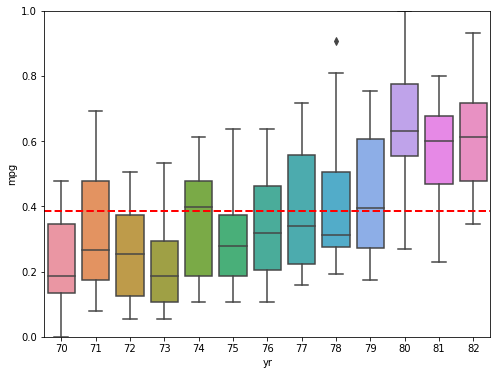

In [29]:
var = 'yr'
mpg_df_plt = pd.concat([mpg_df_scale['mpg'], mpg_df_scale[var]], axis=1)
f, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x=var, y="mpg", data=mpg_df_plt)
fig.axis(ymin=0, ymax=1)
plt.axhline(mpg_df_scale.mpg.mean(),color='r',linestyle='dashed',linewidth=2)

In [30]:
#And MPG distribution for cylinders

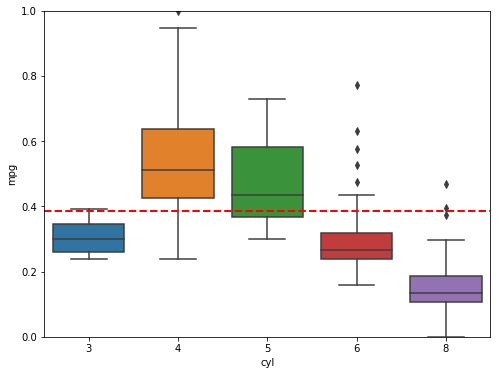

In [31]:
var = 'cyl'
mpg_df_plt = pd.concat([mpg_df_scale['mpg'], mpg_df_scale[var]], axis=1)
f, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x=var, y="mpg", data=mpg_df_plt)
fig.axis(ymin=0, ymax=1)
plt.axhline(mpg_df_scale.mpg.mean(),color='r',linestyle='dashed',linewidth=2)

In [32]:
#Now that we have looked at the distribution mpg in relation to year and cylinder

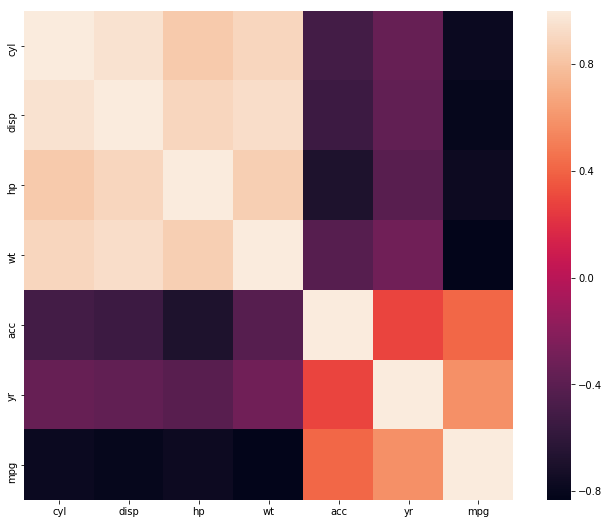

In [33]:
corrmat = mpg_df_scale.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, square=True);

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\axisgrid.py:2065: UserWarning: The `size` parameter has been renamed to `height`; pleaes update your code.
  warnings.warn(msg, UserWarning)


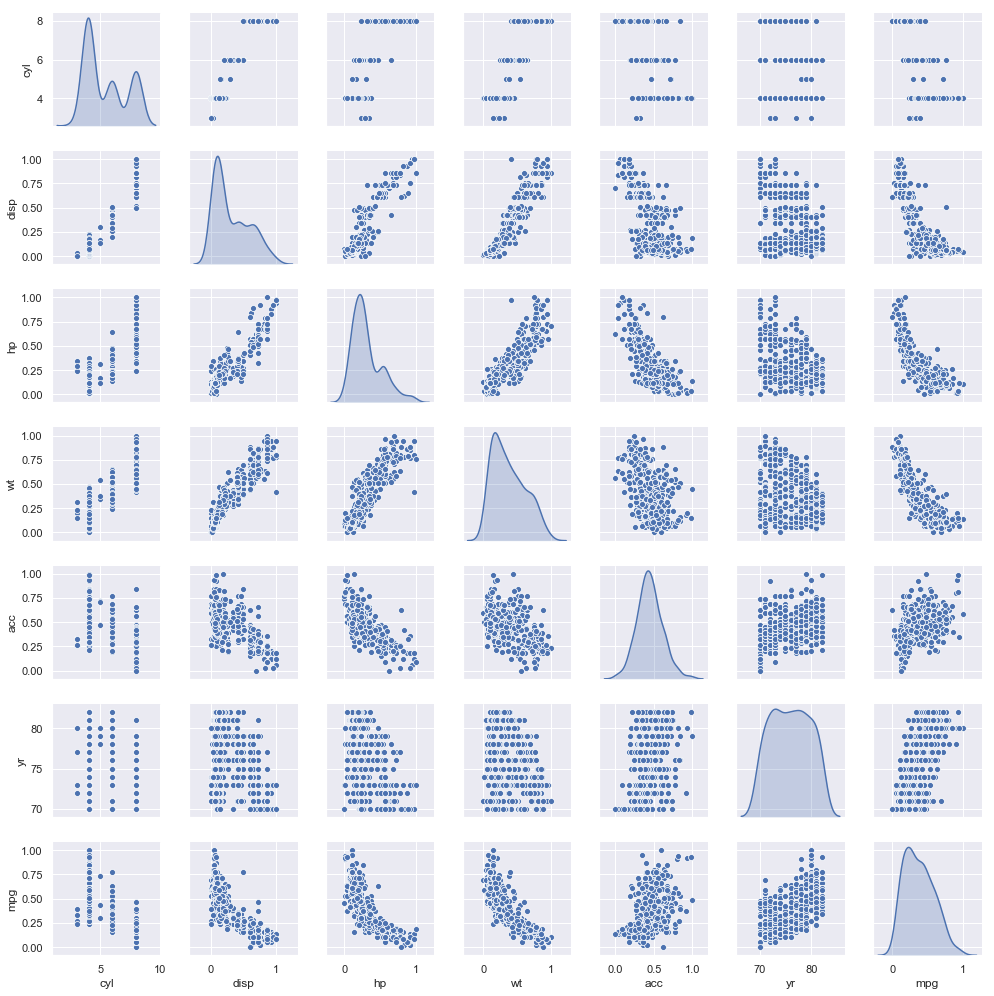

In [34]:
#scatterplot
sns.set()
sns.pairplot(mpg_df_scale, size = 2.0,diag_kind='kde')
plt.show()

In [35]:
mpg_df_scale.pop ('yr')

car name
chevrolet chevelle malibu            70
buick skylark 320                    70
plymouth satellite                   70
amc rebel sst                        70
ford torino                          70
ford galaxie 500                     70
chevrolet impala                     70
plymouth fury iii                    70
pontiac catalina                     70
amc ambassador dpl                   70
dodge challenger se                  70
plymouth 'cuda 340                   70
chevrolet monte carlo                70
buick estate wagon (sw)              70
toyota corona mark ii                70
plymouth duster                      70
amc hornet                           70
ford maverick                        70
datsun pl510                         70
volkswagen 1131 deluxe sedan         70
peugeot 504                          70
audi 100 ls                          70
saab 99e                             70
bmw 2002                             70
amc gremlin                    

In [36]:
mpg_df_scale.head()

,cyl,disp,hp,wt,acc,mpg
car name,,,,,,
chevrolet chevelle malibu,8,0.617571,0.456522,0.536150,0.238095,0.239362
buick skylark 320,8,0.728682,0.646739,0.589736,0.208333,0.159574
plymouth satellite,8,0.645995,0.565217,0.516870,0.178571,0.239362
amc rebel sst,8,0.609819,0.565217,0.516019,0.238095,0.186170
ford torino,8,0.604651,0.510870,0.520556,0.148810,0.212766


In [37]:
cluster_range = range( 2, 6)   # expect 3 to four clusters from the pair panel visual inspection hence restricting from 2 to 6
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(mpg_df_scale)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  cluster_errors.append( clusters.inertia_ )
mpg_clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )
mpg_clusters_df[0:15]

,num_clusters,cluster_errors
0,2,232.557929
1,3,32.126195
2,4,27.258718
3,5,24.096051


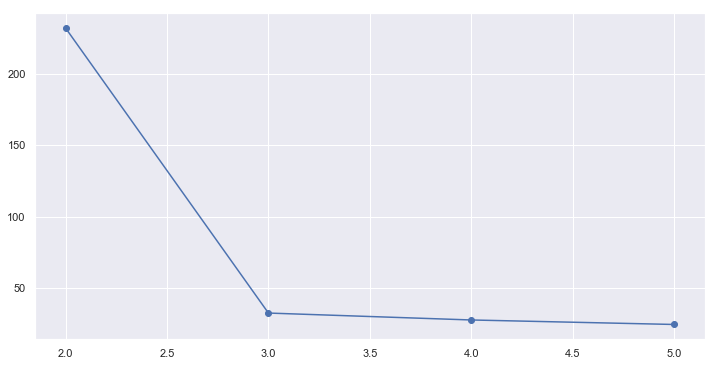

In [38]:
# Elbow plot

plt.figure(figsize=(12,6))
plt.plot( mpg_clusters_df.num_clusters, mpg_clusters_df.cluster_errors, marker = "o" )

In [39]:
# The elbow plot confirms our visual analysis that there are  3 good clusters


In [40]:
cluster = KMeans( n_clusters = 3, random_state = 2354 )
cluster.fit(mpg_df_scale)
mpg_df_scale_copy = mpg_df_scale.copy(deep = True)  # Creating a mirror copy for later re-use instead of building repeatedly

In [41]:
centroids = cluster.cluster_centers_
centroids

array([[8.        , 0.71578736, 0.61033136, 0.70930492, 0.2949607 ,
        0.15859327],
       [3.98564593, 0.10629551, 0.17930882, 0.1984486 , 0.50911369,
        0.53599969],
       [5.97674419, 0.38429181, 0.29970298, 0.44933437, 0.49425526,
        0.29394483]])

In [42]:
centroid_df = pd.DataFrame(centroids, columns = list(mpg_df_scale) )
centroid_df

,cyl,disp,hp,wt,acc,mpg
0,8.000000,0.715787,0.610331,0.709305,0.294961,0.158593
1,3.985646,0.106296,0.179309,0.198449,0.509114,0.536000
2,5.976744,0.384292,0.299703,0.449334,0.494255,0.293945


In [43]:
prediction=cluster.predict(mpg_df_scale)
mpg_df_scale["GROUP"] = prediction     # Creating a new column "GROUP" which will hold the cluster id of each record

In [44]:
#Instead of interpreting the neumerical values of the centroids, let us do a visual analysis by converting the
#centroids and the data in the cluster into box plots.


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001B09923AE10>,
      dtype=object)

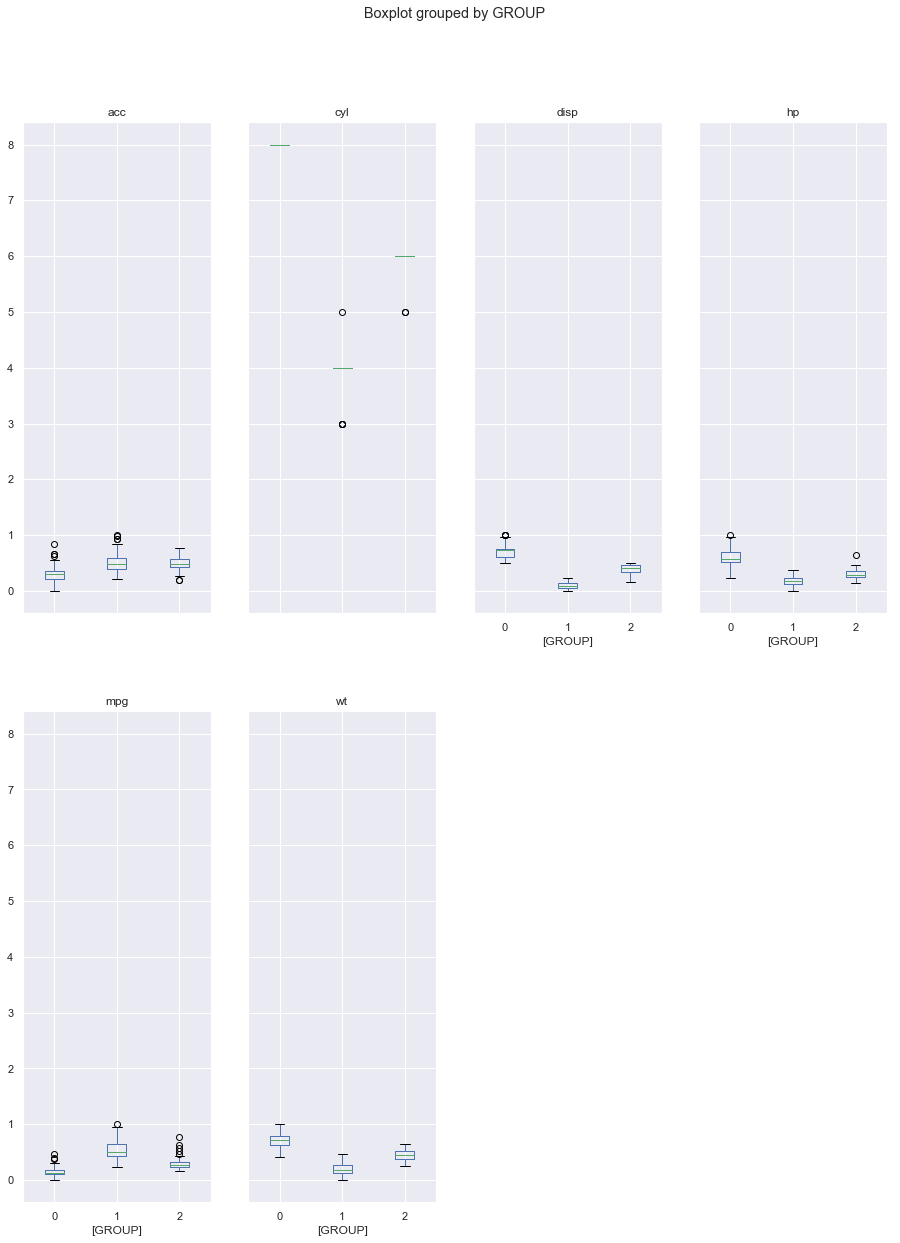

In [45]:
import matplotlib.pylab as plt

mpg_df_scale.boxplot(by = 'GROUP',  layout=(2,4), figsize=(15, 20))

In [46]:
mpg_df_scale.shape

(398, 7)

In [202]:
#Identifying and handling outliers

In [225]:
#concat_data_0=concat_data.loc[concat_data['GROUP']==0]
#concat_data_1=concat_data.loc[concat_data['GROUP']==1]
#concat_data_2=concat_data.loc[concat_data['GROUP']==2]

In [47]:
concat_data_0=mpg_df_scale.loc[mpg_df_scale['GROUP']==0]
concat_data_1=mpg_df_scale.loc[mpg_df_scale['GROUP']==1]
concat_data_2=mpg_df_scale.loc[mpg_df_scale['GROUP']==2]

In [48]:
X_0 = concat_data_0[concat_data_0.columns[1:-2]] 
# -2 because dropping Group and mpg
y_0= concat_data_0['mpg'].astype('float64')
#y = mpg_df['hp'].astype('float64')

In [49]:
from sklearn import model_selection
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_0_train, X_0_test, y_0_train, y_0_test = model_selection.train_test_split(X_0, y_0, test_size=test_size, random_state=seed)

In [50]:
X_0_train.head()

,disp,hp,wt,acc
car name,,,,
dodge diplomat,0.645995,0.510870,0.601644,0.309524
buick century luxus (sw),0.728682,0.565217,0.874965,0.386905
ford ltd,0.731266,0.554348,0.863056,0.327381
plymouth fury iii,0.645995,0.565217,0.715055,0.327381
dodge coronet brougham,0.645995,0.565217,0.730649,0.297619


In [52]:
from sklearn.linear_model import LinearRegression

regression_model = LinearRegression()

regression_model.fit(X_0_train, y_0_train)

regression_model.coef_

array([ 0.18833058, -0.13325913, -0.31969314,  0.15357593])

In [53]:
regression_model.intercept_

0.28498692699564276

In [54]:
regression_model.score(X_0_test, y_0_test)

0.5708793803740821

In [55]:
X_1 = concat_data_1[concat_data_1.columns[1:-2]] 
# -2 because dropping Group and mpg
y_1= concat_data_1['mpg'].astype('float64')
#y = mpg_df['hp'].astype('float64')

In [56]:
from sklearn import model_selection
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_1_train, X_1_test, y_1_train, y_1_test = model_selection.train_test_split(X_1, y_1, test_size=test_size, random_state=seed)

In [57]:
X_1_train.head()

,disp,hp,wt,acc
car name,,,,
chevrolet camaro,0.214470,0.239130,0.379076,0.553571
volkswagen rabbit custom,0.074935,0.173913,0.092713,0.386905
fiat 124 tc,0.124031,0.157609,0.179473,0.357143
toyota carina,0.074935,0.228261,0.188829,0.654762
peugeot 504,0.134367,0.228261,0.469804,0.827381


In [58]:
regression_model.fit(X_1_train, y_1_train)

regression_model.coef_

array([ 0.2565504 , -1.0312746 , -0.37465107, -0.07272584])

In [59]:
regression_model.intercept_

0.8133340191285198

In [60]:
regression_model.score(X_1_test, y_1_test)

0.3563289774320042

In [61]:
X_2 = concat_data_2[concat_data_2.columns[1:-2]] 
# -2 because dropping Group and mpg
y_2= concat_data_2['mpg'].astype('float64')
#y = mpg_df['hp'].astype('float64')

In [62]:
from sklearn import model_selection
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_2_train, X_2_test, y_2_train, y_2_test = model_selection.train_test_split(X_2, y_2, test_size=test_size, random_state=seed)

In [63]:
X_2_train.head()

,disp,hp,wt,acc
car name,,,,
buick skylark,0.421189,0.320652,0.513751,0.529762
plymouth volare custom,0.405685,0.293478,0.571874,0.577381
ford maverick,0.341085,0.258152,0.357811,0.535714
buick century special,0.421189,0.320652,0.500992,0.464286
chevroelt chevelle malibu,0.470284,0.320652,0.647576,0.625000


In [64]:
regression_model.fit(X_2_train, y_2_train)

regression_model.coef_

array([-0.30936535, -0.17377338, -0.33535351, -0.07803668])

In [65]:
regression_model.intercept_

0.6648188404455094

In [66]:
regression_model.score(X_2_test, y_2_test)

-0.17989288261089342

In [67]:
mpg_df_scale.shape

(398, 7)

In [68]:
X_2.shape

(86, 4)

In [69]:
X_1.shape

(209, 4)

In [70]:
X_0.shape

(103, 4)

In [73]:
X_full = mpg_df_scale[mpg_df_scale.columns[1:-2]] 
# -2 because dropping Group and mpg
y_full= mpg_df_scale['mpg'].astype('float64')
#y = mpg_df['hp'].astype('float64')

In [74]:
from sklearn import model_selection
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_full_train, X_full_test, y_full_train, y_full_test = model_selection.train_test_split(X_full, y_full, test_size=test_size, random_state=seed)

In [75]:
regression_model.fit(X_full_train, y_full_train)

regression_model.coef_

array([-0.1271085 , -0.12971201, -0.49822369, -0.02669439])

In [76]:
regression_model.intercept_

0.6742418992143329

In [77]:
regression_model.score(X_full_test, y_full_test)

0.6494363110736885

In [ ]:
# outliers have not been treated. 
# Better results can be expected if outliers are treated using PCA for instance
# standard scaler has not been used. if standard scaler function is used may be the output will be better
# After K means , each cluster has been grouped moved into seperated dataframes. 
# With Seperate clusters the linear regression models have been built and scores created
# after looking at the results may be the alternative models have to be worked out for cluster with Group 2
# OVerall if liner regression is done without clustering the model result is better-off than addressing each cluster seperately
# Would conclude telling that though the scope of the assignment is complete, this is not the optimum model that could be concluded.